In [1]:
import torch.nn as nn
import torch
import pandas as pd


In [2]:
data = pd.read_csv("data/Pokemon.csv")
data.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## **Descripción de la tarea**

Trabajaremos con un dataset de la serie "Pokémon" que desglosa las capacidades de cada criatura en atributos cuantitativos. La tarea consiste en utilizar arquitecturas de redes neuronales simples (MLP) para identificar patrones que distingan a los Pokémon Legendarios del resto. Deberán procesar estas variables y entrenar un clasificador que maximice la capacidad predictiva sobre la variable objetivo "Legendary".

Consideraciones:
- Debe entregarlo a más tardar el 29 de mayo a las 18:00 horas.
- Debe ser entregado al correo luis.llanca@uach.cl con el asunto "Tarea-1-MLP", el archivo debe llamarse NG-MLP-Tarea1.ipynb donde NG es el número de grupo. Es importante que el asunto sea exactamente el mismo. También, se les pedirá que se anoten en la plantilla (que se compartirá posteriormente) para una pequeña interrogación.
- Por cada 20 minutos de retraso, se descontará una décima de la nota. 
- Si necesitan ayuda, pueden escribir a los correos luis.llanca@uach.cl, luis.llanca@cenia.cl o escribir al discord de usuario: llanking (tengo una foto de mi gata). PD: prefiero mucho más el discord. 

### **Explicación del dataset**
Explique el dataset en detalle, incluyendo como mínimo una pequeña descripción de cada columna, el tipo de datos que contiene cada columna, y cualquier información adicional relevante para entender el dataset.

El dataset contiene información de los Pokémon de primera a sexta generación, incluyendo sus estadísticas, tipos elementales, generación y una variable indicadora de si son o no legendarios. También incluye un identificador único de cada Pokémon, el cual puede repetirse para distintas versiones del mismo, como megaevoluciones, diferentes formas (como en el caso de Tornadus), tamaños, etc.

#### **Descripción de las columnas:**

| Columna    | Tipo de dato | Descripción                                                                                                       |
| :--------- | :----------- | :---------------------------------------------------------------------------------------------------------------- |
| #          | Numérica     | Identificador único para distinguir los Pokémon; se repite si un mismo Pokémon tiene múltiples formas o versiones |
| Name       | String       | Nombre del Pokémon o de su versión específica                                                                     |
| Type 1     | String       | Tipo elemental primario del Pokémon                                                                               |
| Type 2     | String o NaN | Tipo elemental secundario del Pokémon                                                                             |
| Total      | Numérica     | Suma total de las estadísticas                                                                                    |
| HP         | Numérica     | Puntos de vida del Pokémon                                                                                        |
| Attack     | Numérica     | Puntos de ataque del Pokémon                                                                                      |
| Defense    | Numérica     | Puntos de defensa del Pokémon                                                                                     |
| Sp. Atk    | Numérica     | Puntos de ataque especial del Pokémon                                                                             |
| Sp. Def    | Numérica     | Puntos de defensa especial del Pokémon                                                                            |
| Speed      | Numérica     | Puntos de velocidad del Pokémon                                                                                   |
| Generation | Numérica     | Variable categórica numérica que indica la generación del Pokémon                                                 |
| Legendary  | Booleana     | Variable indicadora que señala si el Pokémon es legendario                                                        |

#### **Consideraciones**

Se debe tener en cuenta, al analizar el dataset, la existencia del *power creep* en Pokémon, donde los Pokémon de generaciones más recientes tienden a ser más fuertes que los de generaciones anteriores. Esto podría generar que algunos Pokémon de primera generación no sean identificados como legendarios por el modelo.

También es importante considerar que el dataset está desbalanceado por naturaleza, ya que existen aproximadamente 60 Pokémon legendarios, mientras que el resto corresponde a Pokémon no legendarios.

Finalmente, se debe tener en cuenta la presencia de los pseudo-legendarios, que son Pokémon cuyas estadísticas totales superan los 600 puntos, pero que no son clasificados como legendarios.

### **Preparación del dataset**

Realice una preparación del dataset según lo que considere necesario para el entrenamiento de un modelo de clasificación. Justifique las decisiones que tome en este proceso.

In [3]:
# Primer filtro, quitar las distintas versiones de un mismo pokemon.
# Esto quita duplicados guiandose por la columna #, y se queda con la primera fila en casos de duplicados (Porque notamos que el dataset venia ordenado, osea las versiones de Charizar estaban debajo de el pokemon Charizard)
# # | Pokemon
# 6 | Charizard
# 6 | CharizardMega Charizard X
# 6 | CharizardMega Charizard Y
# Entonces nos quedamos con el primero simplemente agrupando por #
df_clean = data.drop_duplicates(subset="#", keep="first")

# Segundo filtro, aplicar el one hot encoding a las variables categoricas (Type 1, Type2 y Generacion)
# Se rellenan los NaN con None, para aplicar los dummies
df_clean["Type 2"] = df_clean["Type 2"].fillna("None")
# Se aplica el get dummies, que pasa las posibles valores de la columna a columnas tipo flag
df_encoded = pd.get_dummies(
    df_clean,
    columns=["Type 1", "Type 2", "Generation"],
    prefix=["T1", "T2", "Gen"]
)

In [4]:
X = df_encoded.drop(columns=["Total", "#", "Name"])     # Inputs
y = df_encoded["Legendary"]                             # Objetivo

In [5]:
# Convertir bool a int en todo el DataFrame X
X = X.astype({col: int for col in X.select_dtypes(include='bool').columns})

# Convertir Legendary a int
y = y.astype(int)

# Crear tensores
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

### **Definición del modelo**  
Defina al menos 3 arquitecturas de redes neuronales simples (MLP) para el problema de clasificación. Justifique las decisiones que tome en la definición de cada arquitectura. Las definiciones se deben hacer en un archivo ```models.py``` e importarlas en este cuadernillo. Debe seleccionar "la mejor" arquitectura para el entrenamiento, y justificar su elección.

Se Definieron 3 arquiteturas que vanL

- 50 Neuronas -> 16 Neuronas -> 1 Neurona
- 50 Neuronas -> 32 Neuronas -> 16 Neuronas -> 1 Neurona
- 50 Neuronas -> 32 Neuronas -> 32 Neuronas -> 16 Neuronas -> 1 Neurona

In [6]:
from models import MLP1, MLP2, MLP3

model1 = MLP1(input_dim=X.shape[1])
model2 = MLP2(input_dim=X.shape[1])
model3 = MLP3(input_dim=X.shape[1])

### **Definición de optimizador y función de costo**
Defina un optimizador y una función de costo adecuado para el entrenamiento del modelo. Justifique sus decisiones.

In [7]:
criterion = nn.BCEWithLogitsLoss()
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.001)

### **Entrenamiento del modelo**
Entrene el modelo seleccionado utilizando el dataset preparado. Justifique las decisiones que tome en el proceso de entrenamiento, incluyendo la selección de hiperparámetros, el número de épocas, el tamaño del batch, etc.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X.values,
    y.values,
    test_size=0.2,
    random_state=42
)

import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

from torch.utils.data import DataLoader

loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [9]:
epochs = 100
patience = 10

best_val_loss = float("inf")
counter = 0

for epoch in range(epochs):
    # -------- TRAIN --------
    model1.train()
    total_loss = 0

    for xb, yb in loader:
        optimizer1.zero_grad()

        outputs = model1(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer1.step()

        total_loss += loss.item()

    # -------- VALIDATION --------
    model1.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model1(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {total_loss:.4f}, Val Loss: {val_loss:.4f}")

    # -------- EARLY STOPPING --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping activado")
        break

Epoch 1, Train Loss: 8.5416, Val Loss: 1.5569
Epoch 2, Train Loss: 7.4231, Val Loss: 1.4367
Epoch 3, Train Loss: 6.2278, Val Loss: 1.3851
Epoch 4, Train Loss: 6.6453, Val Loss: 1.3378
Epoch 5, Train Loss: 6.2024, Val Loss: 1.4024
Epoch 6, Train Loss: 6.1697, Val Loss: 1.3004
Epoch 7, Train Loss: 5.4706, Val Loss: 1.2673
Epoch 8, Train Loss: 5.8212, Val Loss: 1.2895
Epoch 9, Train Loss: 5.2996, Val Loss: 1.2272
Epoch 10, Train Loss: 4.9093, Val Loss: 1.2055
Epoch 11, Train Loss: 5.0538, Val Loss: 1.2130
Epoch 12, Train Loss: 5.2178, Val Loss: 1.1923
Epoch 13, Train Loss: 5.1185, Val Loss: 1.2067
Epoch 14, Train Loss: 5.3381, Val Loss: 1.2074
Epoch 15, Train Loss: 5.1495, Val Loss: 1.1683
Epoch 16, Train Loss: 4.7354, Val Loss: 1.1168
Epoch 17, Train Loss: 4.8710, Val Loss: 1.0946
Epoch 18, Train Loss: 4.4855, Val Loss: 1.0868
Epoch 19, Train Loss: 4.4550, Val Loss: 1.0563
Epoch 20, Train Loss: 4.3087, Val Loss: 1.0546
Epoch 21, Train Loss: 4.4867, Val Loss: 1.0252
Epoch 22, Train Loss: 

In [26]:
epochs = 100
patience = 10

best_val_loss = float("inf")
counter = 0

for epoch in range(epochs):
    # -------- TRAIN --------
    model2.train()
    total_loss = 0

    for xb, yb in loader:
        optimizer2.zero_grad()

        outputs = model2(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer2.step()

        total_loss += loss.item()

    # -------- VALIDATION --------
    model2.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model2(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {total_loss:.4f}, Val Loss: {val_loss:.4f}")

    # -------- EARLY STOPPING --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping activado")
        break

Epoch 1, Train Loss: 13.7108, Val Loss: 3.7512
Epoch 2, Train Loss: 12.3138, Val Loss: 3.2786
Epoch 3, Train Loss: 10.8216, Val Loss: 2.9023
Epoch 4, Train Loss: 9.5333, Val Loss: 2.4356
Epoch 5, Train Loss: 8.2746, Val Loss: 2.0833
Epoch 6, Train Loss: 7.0883, Val Loss: 1.7778
Epoch 7, Train Loss: 6.4377, Val Loss: 1.5289
Epoch 8, Train Loss: 5.5741, Val Loss: 1.3053
Epoch 9, Train Loss: 4.8759, Val Loss: 1.0866
Epoch 10, Train Loss: 4.4629, Val Loss: 0.9856
Epoch 11, Train Loss: 3.9777, Val Loss: 0.8263
Epoch 12, Train Loss: 3.6616, Val Loss: 0.7270
Epoch 13, Train Loss: 3.2200, Val Loss: 0.6096
Epoch 14, Train Loss: 2.9733, Val Loss: 0.5509
Epoch 15, Train Loss: 2.6553, Val Loss: 0.4833
Epoch 16, Train Loss: 2.3883, Val Loss: 0.4670
Epoch 17, Train Loss: 2.2203, Val Loss: 0.4317
Epoch 18, Train Loss: 2.1581, Val Loss: 0.3992
Epoch 19, Train Loss: 2.2463, Val Loss: 0.3618
Epoch 20, Train Loss: 2.0316, Val Loss: 0.3520
Epoch 21, Train Loss: 2.0121, Val Loss: 0.3329
Epoch 22, Train Los

In [28]:
epochs = 100
patience = 10

best_val_loss = float("inf")
counter = 0

for epoch in range(epochs):
    # -------- TRAIN --------
    model3.train()
    total_loss = 0

    for xb, yb in loader:
        optimizer3.zero_grad()

        outputs = model3(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer3.step()

        total_loss += loss.item()

    # -------- VALIDATION --------
    model3.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model3(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {total_loss:.4f}, Val Loss: {val_loss:.4f}")

    # -------- EARLY STOPPING --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping activado")
        break

Epoch 1, Train Loss: 14.5399, Val Loss: 3.8334
Epoch 2, Train Loss: 12.8118, Val Loss: 3.4070
Epoch 3, Train Loss: 10.9918, Val Loss: 2.9056
Epoch 4, Train Loss: 9.1726, Val Loss: 2.3716
Epoch 5, Train Loss: 7.8354, Val Loss: 2.0373
Epoch 6, Train Loss: 6.4129, Val Loss: 1.5683
Epoch 7, Train Loss: 5.3256, Val Loss: 1.1883
Epoch 8, Train Loss: 4.6293, Val Loss: 0.9606
Epoch 9, Train Loss: 3.9546, Val Loss: 0.7311
Epoch 10, Train Loss: 3.5038, Val Loss: 0.6926
Epoch 11, Train Loss: 3.1534, Val Loss: 0.5801
Epoch 12, Train Loss: 2.8847, Val Loss: 0.4986
Epoch 13, Train Loss: 2.6647, Val Loss: 0.4215
Epoch 14, Train Loss: 2.4007, Val Loss: 0.3804
Epoch 15, Train Loss: 2.4291, Val Loss: 0.4168
Epoch 16, Train Loss: 2.0471, Val Loss: 0.3165
Epoch 17, Train Loss: 1.9888, Val Loss: 0.2829
Epoch 18, Train Loss: 2.0590, Val Loss: 0.2462
Epoch 19, Train Loss: 1.9116, Val Loss: 0.2247
Epoch 20, Train Loss: 1.7532, Val Loss: 0.2507
Epoch 21, Train Loss: 1.6974, Val Loss: 0.2385
Epoch 22, Train Los

### **Evaluación del modelo**
Evalúe el modelo utilizando métricas adecuadas para este problema de clasificación. Justifique la selección de las métricas utilizadas y discuta los resultados obtenidos. 

In [22]:
import torch
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt

def evaluar_modelo(model, X, y, threshold=0.5):
    model.eval()
    
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

    y_true = y.cpu().numpy().ravel()
    y_pred = preds.cpu().numpy().ravel()

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    # 🔥 etiquetas personalizadas
    labels = ["No Legendario", "Legendario"]

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")

    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    return cm, acc, prec, rec, f1

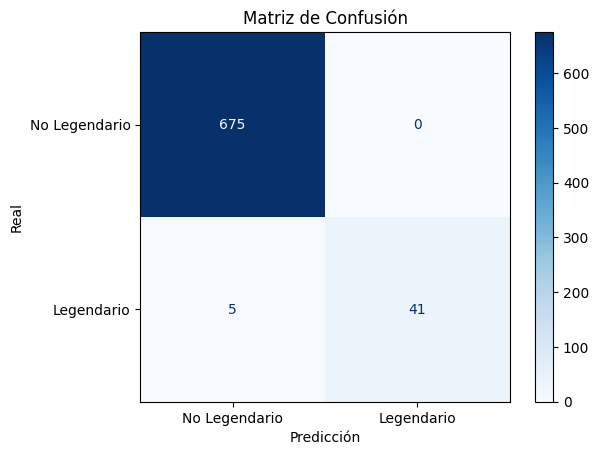

Accuracy : 0.9931
Precision: 1.0000
Recall   : 0.8913
F1-score : 0.9425


In [23]:
cm = evaluar_modelo(model1, X_tensor, y_tensor)

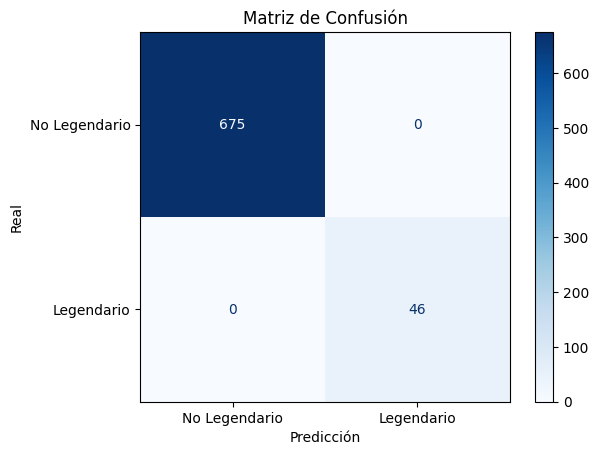

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


In [27]:
cm = evaluar_modelo(model2, X_tensor, y_tensor)

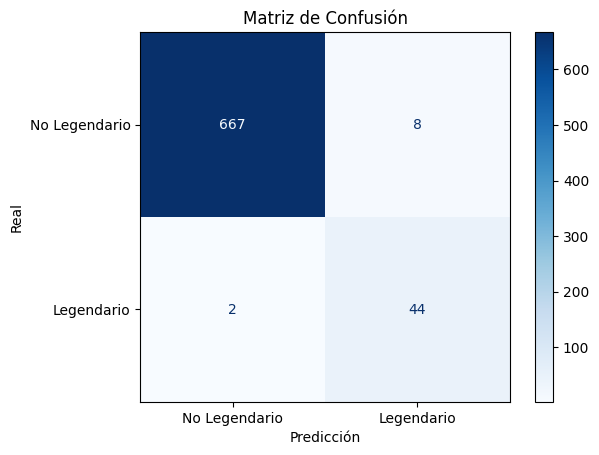

Accuracy : 0.9861
Precision: 0.8462
Recall   : 0.9565
F1-score : 0.8980


In [29]:
cm = evaluar_modelo(model3, X_tensor, y_tensor)

In [40]:
def obtener_errores(model, X, y, threshold=0.5):
    model.eval()
    
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

    y_true = y.cpu().numpy().ravel()
    y_pred = preds.cpu().numpy().ravel()

    # 🔥 índices donde se equivoca
    errores_idx = (y_true != y_pred)

    return errores_idx, y_true, y_pred, probs.cpu().numpy().ravel()
    
errores_idx, y_true, y_pred, probs = obtener_errores(model3, X_tensor, y_tensor)

import numpy as np

idxs = np.where(errores_idx)[0]

# Recuperar los índices originales del DataFrame
df_eval = df_clean.reset_index(drop=True).iloc[idxs].copy()
df_eval["Probabilidad"] = probs[idxs]
df_eval["Predicho_Legendario"] = y_pred[idxs].astype(bool)

# Columnas relevantes
print(df_eval[["Name", "Type 1", "Type 2", "Total", "HP", "Attack", 
               "Defense", "Sp. Atk", "Sp. Def", "Speed", 
               "Legendary", "Predicho_Legendario", "Probabilidad"]])

          Name   Type 1    Type 2  Total   HP  Attack  Defense  Sp. Atk  \
94        Onix     Rock    Ground    385   35      45      160       30   
150        Mew  Psychic      None    600  100     100      100      100   
244    Suicune    Water      None    580  100      75      115       90   
250     Celebi  Psychic     Grass    600  100     100      100      100   
288    Slaking   Normal      None    670  150     160      100       95   
489    Manaphy    Water      None    600  100     100      100      100   
634  Hydreigon     Dark    Dragon    600   92     105       90      125   
637   Cobalion    Steel  Fighting    580   91      90      129       90   
648   Genesect      Bug     Steel    600   71     120       95      120   
705     Goodra   Dragon      None    600   90     100       70      110   

     Sp. Def  Speed  Legendary  Predicho_Legendario  Probabilidad  
94        45     70      False                 True      0.508383  
150      100    100      False        

### Preguntas finales
1. Sobre la matriz de confusión, interprete los resultados obtenidos. Con sus palabras defina que significa cada tipo de error. ¿Elegiría a Pokémon ubicados en FP o FN para su equipo?
2. Busque un caso mal clasificado por el modelo, e interprete por qué cree que el modelo se equivocó en ese caso.
3. ¿Cúal fue el mayor desafío que enfrentó al realizar esta tarea? ¿Cómo lo solucionó?



### IA Generativa

Con el fin de ocupar IA Generativa de manera responsable, se les pide que respondan a las siguientes preguntas:
1. ¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.
2. ¿En qué parte o partes de la tarea utilizó estas herramientas?